# Short-Common Prediction Diagnostics

Run timestamp-level diagnostics after model predictions are available. The first target is the short_common validation split with lookback 72.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import pandas as pd
from IPython.display import display

from src.data import ORACLE_MODE, SHORT_COMMON_GROUP, build_dataset, load_source_tables
from src.diagnostics import (
    attach_event_context,
    build_model_comparison_frame,
    build_negative_price_events,
    build_prediction_frame,
    plot_error_by_time_bucket,
    plot_prediction_timeline,
    summarize_error_counts,
    summarize_event_detection,
    summarize_price_severity,
    summarize_time_buckets,
)
from src.metrics import evaluate_predictions
from src.models import lstm, tcn, xg_boost

MODEL_MODULES = {"xg_boost": xg_boost, "lstm": lstm, "tcn": tcn}
DATA_MODES = {"short_past": "past", "short_forecast": "forecast", "short_oracle": ORACLE_MODE}
SELECTED_MODELS = ["xg_boost", "lstm", "tcn"]
SELECTED_DATA_MODES = list(DATA_MODES.keys())
SELECTED_SEEDS = [1]
LOOKBACK = 72


d:\codingProjects\CurtailmentProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
feature_combined, _, _ = load_source_tables()
price_series = feature_combined["Price"]

prediction_frames = []
for data_label in SELECTED_DATA_MODES:
    dataset = build_dataset(
        DATA_MODES[data_label],
        comparison_group=SHORT_COMMON_GROUP,
        lookback=LOOKBACK,
        use_cache=True,
    )
    for model_name in SELECTED_MODELS:
        model_module = MODEL_MODULES[model_name]
        for seed in SELECTED_SEEDS:
            prediction = model_module.train_and_predict(dataset, {"seed": seed, "show_progress": False})
            if len(prediction["valid_prob"]) != len(dataset.times_valid):
                raise ValueError(
                    f"{model_name} {data_label} valid_prob length {len(prediction['valid_prob'])} "
                    f"does not match dataset.times_valid length {len(dataset.times_valid)}"
                )
            metrics = evaluate_predictions(prediction["valid_true"], prediction["valid_prob"])
            prediction_frames.append(
                build_prediction_frame(
                    times=dataset.times_valid,
                    y_true=prediction["valid_true"],
                    y_prob=prediction["valid_prob"],
                    threshold=metrics["selected_threshold"],
                    model_name=model_name,
                    data_mode=data_label,
                    seed=seed,
                    split="valid",
                    price_series=price_series,
                )
            )

diagnostic_frame = pd.concat(prediction_frames, ignore_index=True)
display(summarize_error_counts(diagnostic_frame))


,model,data_mode,seed,split,TP,FP,FN,TN,count,positive_rate,precision,recall,F1
0,xg_boost,short_past,1,valid,89,98,95,3390,3672,0.050109,0.475936,0.483696,0.479784
1,lstm,short_past,1,valid,91,252,93,3236,3672,0.050109,0.265306,0.494565,0.345351
2,tcn,short_past,1,valid,94,167,90,3321,3672,0.050109,0.360153,0.510870,0.422472
3,xg_boost,short_forecast,1,valid,117,87,67,3401,3672,0.050109,0.573529,0.635870,0.603093
4,lstm,short_forecast,1,valid,109,87,75,3401,3672,0.050109,0.556122,0.592391,0.573684
5,tcn,short_forecast,1,valid,124,90,60,3398,3672,0.050109,0.579439,0.673913,0.623116
6,xg_boost,short_oracle,1,valid,115,99,69,3389,3672,0.050109,0.537383,0.625000,0.577889
7,lstm,short_oracle,1,valid,117,149,67,3339,3672,0.050109,0.439850,0.635870,0.520000
8,tcn,short_oracle,1,valid,128,109,56,3379,3672,0.050109,0.540084,0.695652,0.608076


In [ ]:
events = build_negative_price_events(
    price_series.loc[diagnostic_frame["timestamp"].min():diagnostic_frame["timestamp"].max()]
)
diagnostic_with_events = attach_event_context(diagnostic_frame, events, neighbor_hours=24)

price_quantiles, price_bins = summarize_price_severity(diagnostic_with_events)
time_summary = summarize_time_buckets(diagnostic_with_events)
event_summary = summarize_event_detection(diagnostic_with_events)

display(price_quantiles)

display(price_bins)
display(time_summary)
display(event_summary)


,model,data_mode,seed,split,error_type,count,price_mean,price_min,price_p10,price_median,price_p90
0,xg_boost,short_past,1,valid,TN,3390,93.756413,0.00,45.911,91.940,128.722
1,xg_boost,short_past,1,valid,FP,98,18.727041,0.00,0.000,5.065,69.378
2,xg_boost,short_past,1,valid,FN,95,-2.923789,-20.09,-9.260,-1.010,-0.010
3,xg_boost,short_past,1,valid,TP,89,-6.142247,-61.08,-15.416,-1.010,-0.010
4,lstm,short_past,1,valid,TN,3236,95.750720,0.00,54.680,92.965,129.850
5,lstm,short_past,1,valid,FP,252,38.968889,0.00,0.000,39.530,79.242
6,lstm,short_past,1,valid,TP,91,-6.713077,-61.08,-15.600,-1.500,-0.010
7,lstm,short_past,1,valid,FN,93,-2.296022,-20.05,-5.848,-0.720,-0.010
8,tcn,short_past,1,valid,TN,3321,94.830316,0.00,50.940,92.330,129.300
9,tcn,short_past,1,valid,FP,167,28.371317,0.00,0.000,13.030,72.386


error_type,model,data_mode,seed,split,price_bin,TP,FP,FN,TN
0,xg_boost,short_past,1,valid,<-50,3,0,0,0
1,xg_boost,short_past,1,valid,"[-50,-20)",5,0,2,0
2,xg_boost,short_past,1,valid,"[-20,-5)",15,0,16,0
3,xg_boost,short_past,1,valid,"[-5,0)",66,0,77,0
4,xg_boost,short_past,1,valid,"[0,5)",0,49,0,103
5,xg_boost,short_past,1,valid,>=5,0,49,0,3287
6,xg_boost,short_forecast,1,valid,<-50,3,0,0,0
7,xg_boost,short_forecast,1,valid,"[-50,-20)",7,0,0,0
8,xg_boost,short_forecast,1,valid,"[-20,-5)",29,0,2,0
9,xg_boost,short_forecast,1,valid,"[-5,0)",78,0,65,0


,model,data_mode,seed,split,bucket,bucket_value,TP,FP,FN,TN,count,positive_rate,precision,recall,F1
0,xg_boost,short_past,1,valid,hour,0,0,0,3,150,153,0.019608,0.000000,0.000000,0.000000
1,xg_boost,short_past,1,valid,hour,1,0,0,3,150,153,0.019608,0.000000,0.000000,0.000000
2,xg_boost,short_past,1,valid,hour,2,0,0,4,149,153,0.026144,0.000000,0.000000,0.000000
3,xg_boost,short_past,1,valid,hour,3,0,0,3,150,153,0.019608,0.000000,0.000000,0.000000
4,xg_boost,short_past,1,valid,hour,4,0,0,2,151,153,0.013072,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,tcn,short_oracle,1,valid,month,7,11,46,1,686,744,0.016129,0.192982,0.916667,0.318841
338,tcn,short_oracle,1,valid,month,8,43,26,21,654,744,0.086022,0.623188,0.671875,0.646617
339,tcn,short_oracle,1,valid,month,9,39,28,21,632,720,0.083333,0.582090,0.650000,0.614173
340,tcn,short_oracle,1,valid,month,10,35,9,13,687,744,0.064516,0.795455,0.729167,0.760870


,model,data_mode,seed,split,event_id,event_start,event_end,duration_hours,min_price,mean_price,detected_any,detected_hours,missed_hours,event_recall
0,xg_boost,short_past,1,valid,1,2025-07-04 10:00:00+00:00,2025-07-04 13:00:00+00:00,4,-1.56,-0.897500,True,1,3,0.250000
1,xg_boost,short_past,1,valid,2,2025-07-05 09:00:00+00:00,2025-07-05 14:00:00+00:00,6,-2.26,-1.586667,True,6,0,1.000000
2,xg_boost,short_past,1,valid,3,2025-07-19 11:00:00+00:00,2025-07-19 11:00:00+00:00,1,-0.01,-0.010000,True,1,0,1.000000
3,xg_boost,short_past,1,valid,4,2025-07-20 11:00:00+00:00,2025-07-20 11:00:00+00:00,1,-0.01,-0.010000,True,1,0,1.000000
4,xg_boost,short_past,1,valid,5,2025-08-03 08:00:00+00:00,2025-08-03 14:00:00+00:00,7,-10.08,-4.652857,True,6,1,0.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,tcn,short_oracle,1,valid,29,2025-10-03 23:00:00+00:00,2025-10-04 15:00:00+00:00,17,-2.61,-0.700588,True,10,7,0.588235
293,tcn,short_oracle,1,valid,30,2025-10-04 19:00:00+00:00,2025-10-05 14:00:00+00:00,20,-4.98,-2.278500,True,16,4,0.800000
294,tcn,short_oracle,1,valid,31,2025-10-24 11:00:00+00:00,2025-10-24 12:00:00+00:00,2,-0.01,-0.010000,True,2,0,1.000000
295,tcn,short_oracle,1,valid,32,2025-10-25 02:00:00+00:00,2025-10-25 02:00:00+00:00,1,-0.01,-0.010000,False,0,1,0.000000


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='hour', ylabel='Metric'>)

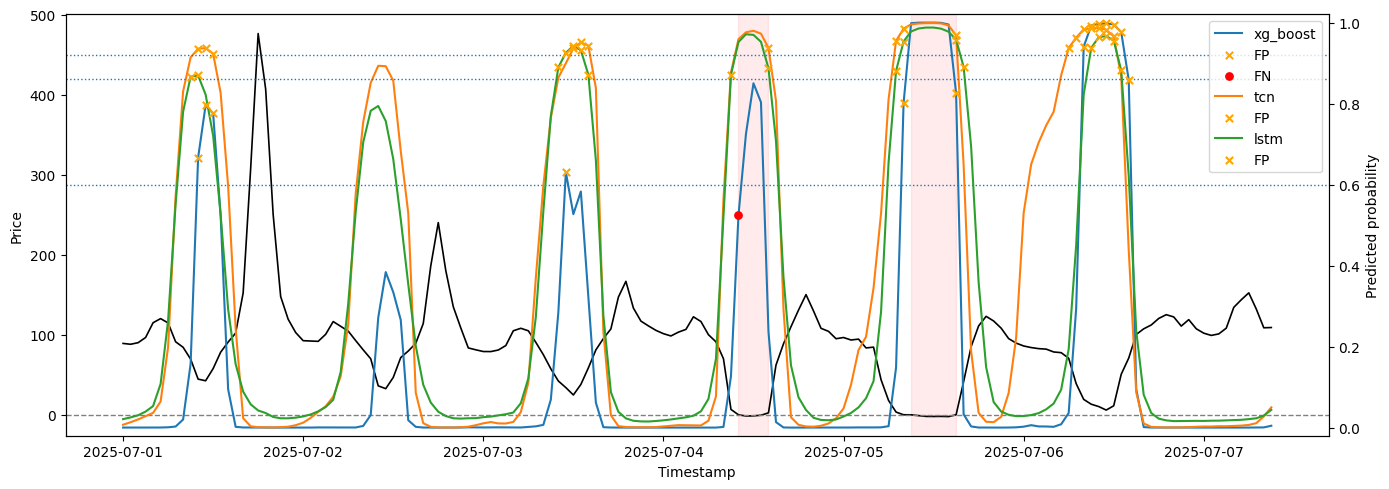

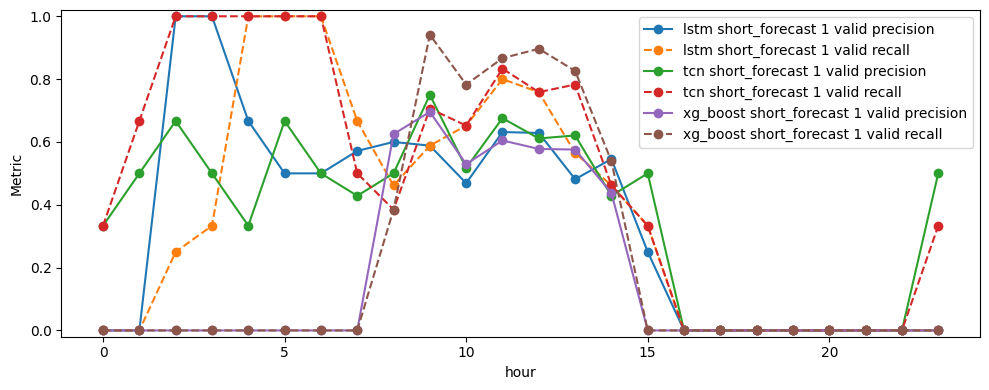

In [4]:
focus_data_mode = "short_forecast"
focus_seed = SELECTED_SEEDS[0]
plot_frame = diagnostic_with_events[
    diagnostic_with_events["data_mode"].eq(focus_data_mode)
    & diagnostic_with_events["seed"].eq(focus_seed)
]
error_times = plot_frame.loc[plot_frame["error_type"].isin(["FP", "FN"]), "timestamp"]
if error_times.empty:
    start = plot_frame["timestamp"].min()
else:
    start = error_times.min() - pd.Timedelta(hours=24)
end = start + pd.Timedelta(hours=168)

plot_prediction_timeline(plot_frame, start=start, end=end)
plot_error_by_time_bucket(time_summary[time_summary["data_mode"].eq(focus_data_mode)], "hour")


In [5]:
comparison_frame = build_model_comparison_frame(
    frame
    for _, frame in diagnostic_with_events[
        diagnostic_with_events["data_mode"].eq(focus_data_mode)
        & diagnostic_with_events["seed"].eq(focus_seed)
    ].groupby("model", sort=False)
)
display(comparison_frame.head())


,timestamp,split,data_mode,seed,y_true,Price,xg_boost_prob,xg_boost_pred,xg_boost_threshold,xg_boost_error,lstm_prob,lstm_pred,lstm_threshold,lstm_error,tcn_prob,tcn_pred,tcn_threshold,tcn_error
0,2025-07-01 00:00:00+00:00,valid,short_forecast,1,0,89.10,0.000154,0,0.6,TN,0.020957,0,0.86,TN,0.007113,0,0.92,TN
1,2025-07-01 01:00:00+00:00,valid,short_forecast,1,0,88.08,0.000257,0,0.6,TN,0.025227,0,0.86,TN,0.013319,0,0.92,TN
2,2025-07-01 02:00:00+00:00,valid,short_forecast,1,0,90.01,0.000256,0,0.6,TN,0.030435,0,0.86,TN,0.020181,0,0.92,TN
3,2025-07-01 03:00:00+00:00,valid,short_forecast,1,0,96.50,0.000194,0,0.6,TN,0.039526,0,0.86,TN,0.028213,0,0.92,TN
4,2025-07-01 04:00:00+00:00,valid,short_forecast,1,0,114.97,0.000168,0,0.6,TN,0.053204,0,0.86,TN,0.036345,0,0.92,TN
